# Lakeside load-profile analysis

Simple site look at **meter demand shapes**, **weather vs kW**, and **GL14 calibration
progress** — then a careful side-by-side of Actual / EnergyPlus / ML (often *different*
calendar days; compare shape, not lock-step magnitude).

Set `LAKESIDE_SITE_ROOT` if needed (default Desktop `sp_creekside`).


In [ ]:
%matplotlib inline
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image

ROOT = Path("..").resolve()
if not (ROOT / "ml").is_dir():
    ROOT = Path(".").resolve()
sys.path.insert(0, str(ROOT / "ml"))
sys.path.insert(0, str(ROOT / "scripts"))
sys.path.insert(0, str(ROOT))

from lakeside.paths import site_root, clean_data_building_dir
from artifact_paths import artifact_paths
from notebook_plots import save_fig, winter_day_panel, apply_notebook_theme

apply_notebook_theme()
SITE = Path(os.environ.get("LAKESIDE_SITE_ROOT", str(site_root())))
CLEAN = clean_data_building_dir()
METER = CLEAN / "CS_ELEC_METER" / "history_wide.csv"
PLOTS = SITE / "plots"
ANALYTICS = PLOTS / "analytics"
PATHS = artifact_paths()
OUT = PATHS["figures"].parent
FIG = PATHS["figures"]
FIG.mkdir(parents=True, exist_ok=True)

print("SITE", SITE, "exists", SITE.is_dir())
print("METER", METER, "exists", METER.is_file())
print("ANALYTICS", ANALYTICS)


SITE C:\Users\ben\OneDrive\Desktop\testing\sp_creekside exists True
METER C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\clean_data\LAKESIDE_ES\CS_ELEC_METER\history_wide.csv exists True
ANALYTICS C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\plots\analytics


## Inventory


In [ ]:
rows = []
for label, p in [
("site_root", SITE),
("meter_csv", METER),
("plots/analytics", ANALYTICS),
("weather_csv", CLEAN / "weather" / "history_wide.csv"),
("gl14_campaign_log", SITE / "eplus" / "scorecards" / "campaign_log.csv"),
("hybrid_walk", OUT / "hybrid_dsm_96_v1_walk.json"),
]:
    rows.append({
    "name": label,
    "path": str(p),
    "exists": p.is_file() if p.suffix else p.is_dir(),
    })
display(pd.DataFrame(rows))


,name,path,exists
0,site_root,C:\Users\ben\OneDrive\Desktop\testing\sp_creek...,True
1,meter_csv,C:\Users\ben\OneDrive\Desktop\testing\sp_creek...,True
2,plots/analytics,C:\Users\ben\OneDrive\Desktop\testing\sp_creek...,True
3,weather_csv,C:\Users\ben\OneDrive\Desktop\testing\sp_creek...,True
4,gl14_campaign_log,C:\Users\ben\OneDrive\Desktop\testing\sp_creek...,True
5,hybrid_walk,C:\Users\ben\Documents\py-bacnet-stacks-playgr...,True


## Site analytics charts (regenerated here)

Runs the same Python that built `plots/analytics/*.png` — meter weekday/weekend,
demand vs Open-Meteo weather, and GL14 iteration charts. No duplicate hand-rolled
diurnal section above this.


C:\Users\ben\Documents\py-bacnet-stacks-playground\vibe_code_apps_22\scripts\demand_weather_charts.py:70: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["ts_local"].dt.to_period("M").astype(str)


chart: C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\plots\analytics\demand_monthly_weekday_weekend_profiles.png
chart: C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\plots\analytics\demand_weekday_weekend_summary.png
weather from C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\clean_data\LAKESIDE_ES\weather\history_wide.csv rows=96953
chart: C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\plots\analytics\demand_vs_web_weather_scatter.png  r=-0.401  n=8082
chart: C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\plots\analytics\demand_vs_web_weather_density.png
chart: C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\plots\analytics\demand_vs_web_weather_scatter_peak_day.png  peak_day=2026-01-26 peak_kw=330.0 peak_hour_utc=2026-01-26 13:00:00+00:00
chart: C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\plots\analytics\gl14_progress_by_iteration.png
chart: C:\Users\ben\OneDrive\Desktop\testing\sp_creekside\plots\analytics\gl14_status_by_iteration.png
chart: C:\Users\

### `demand_weekday_weekend_summary.png`

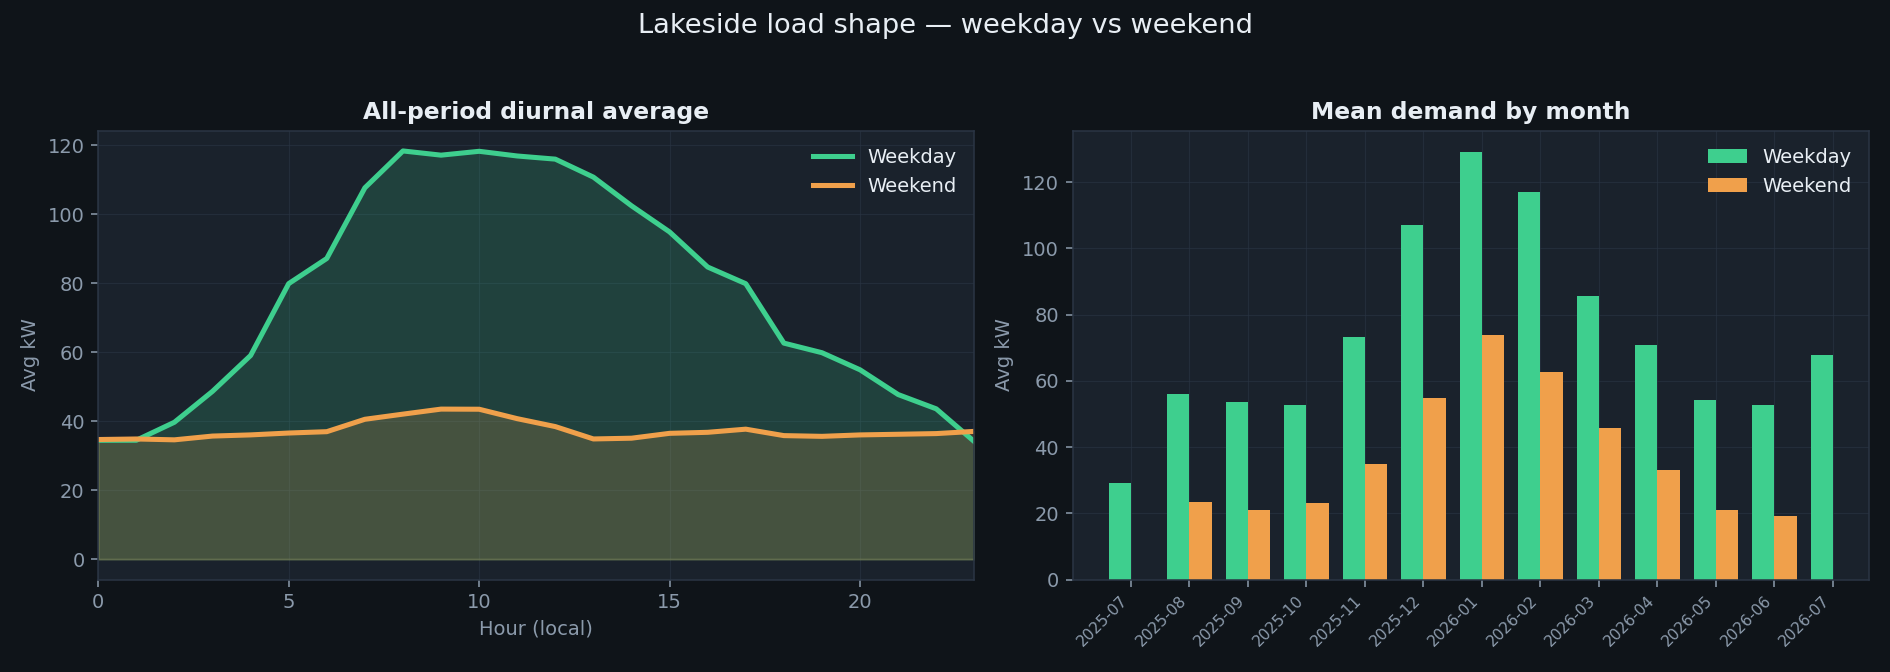

### `demand_monthly_weekday_weekend_profiles.png`

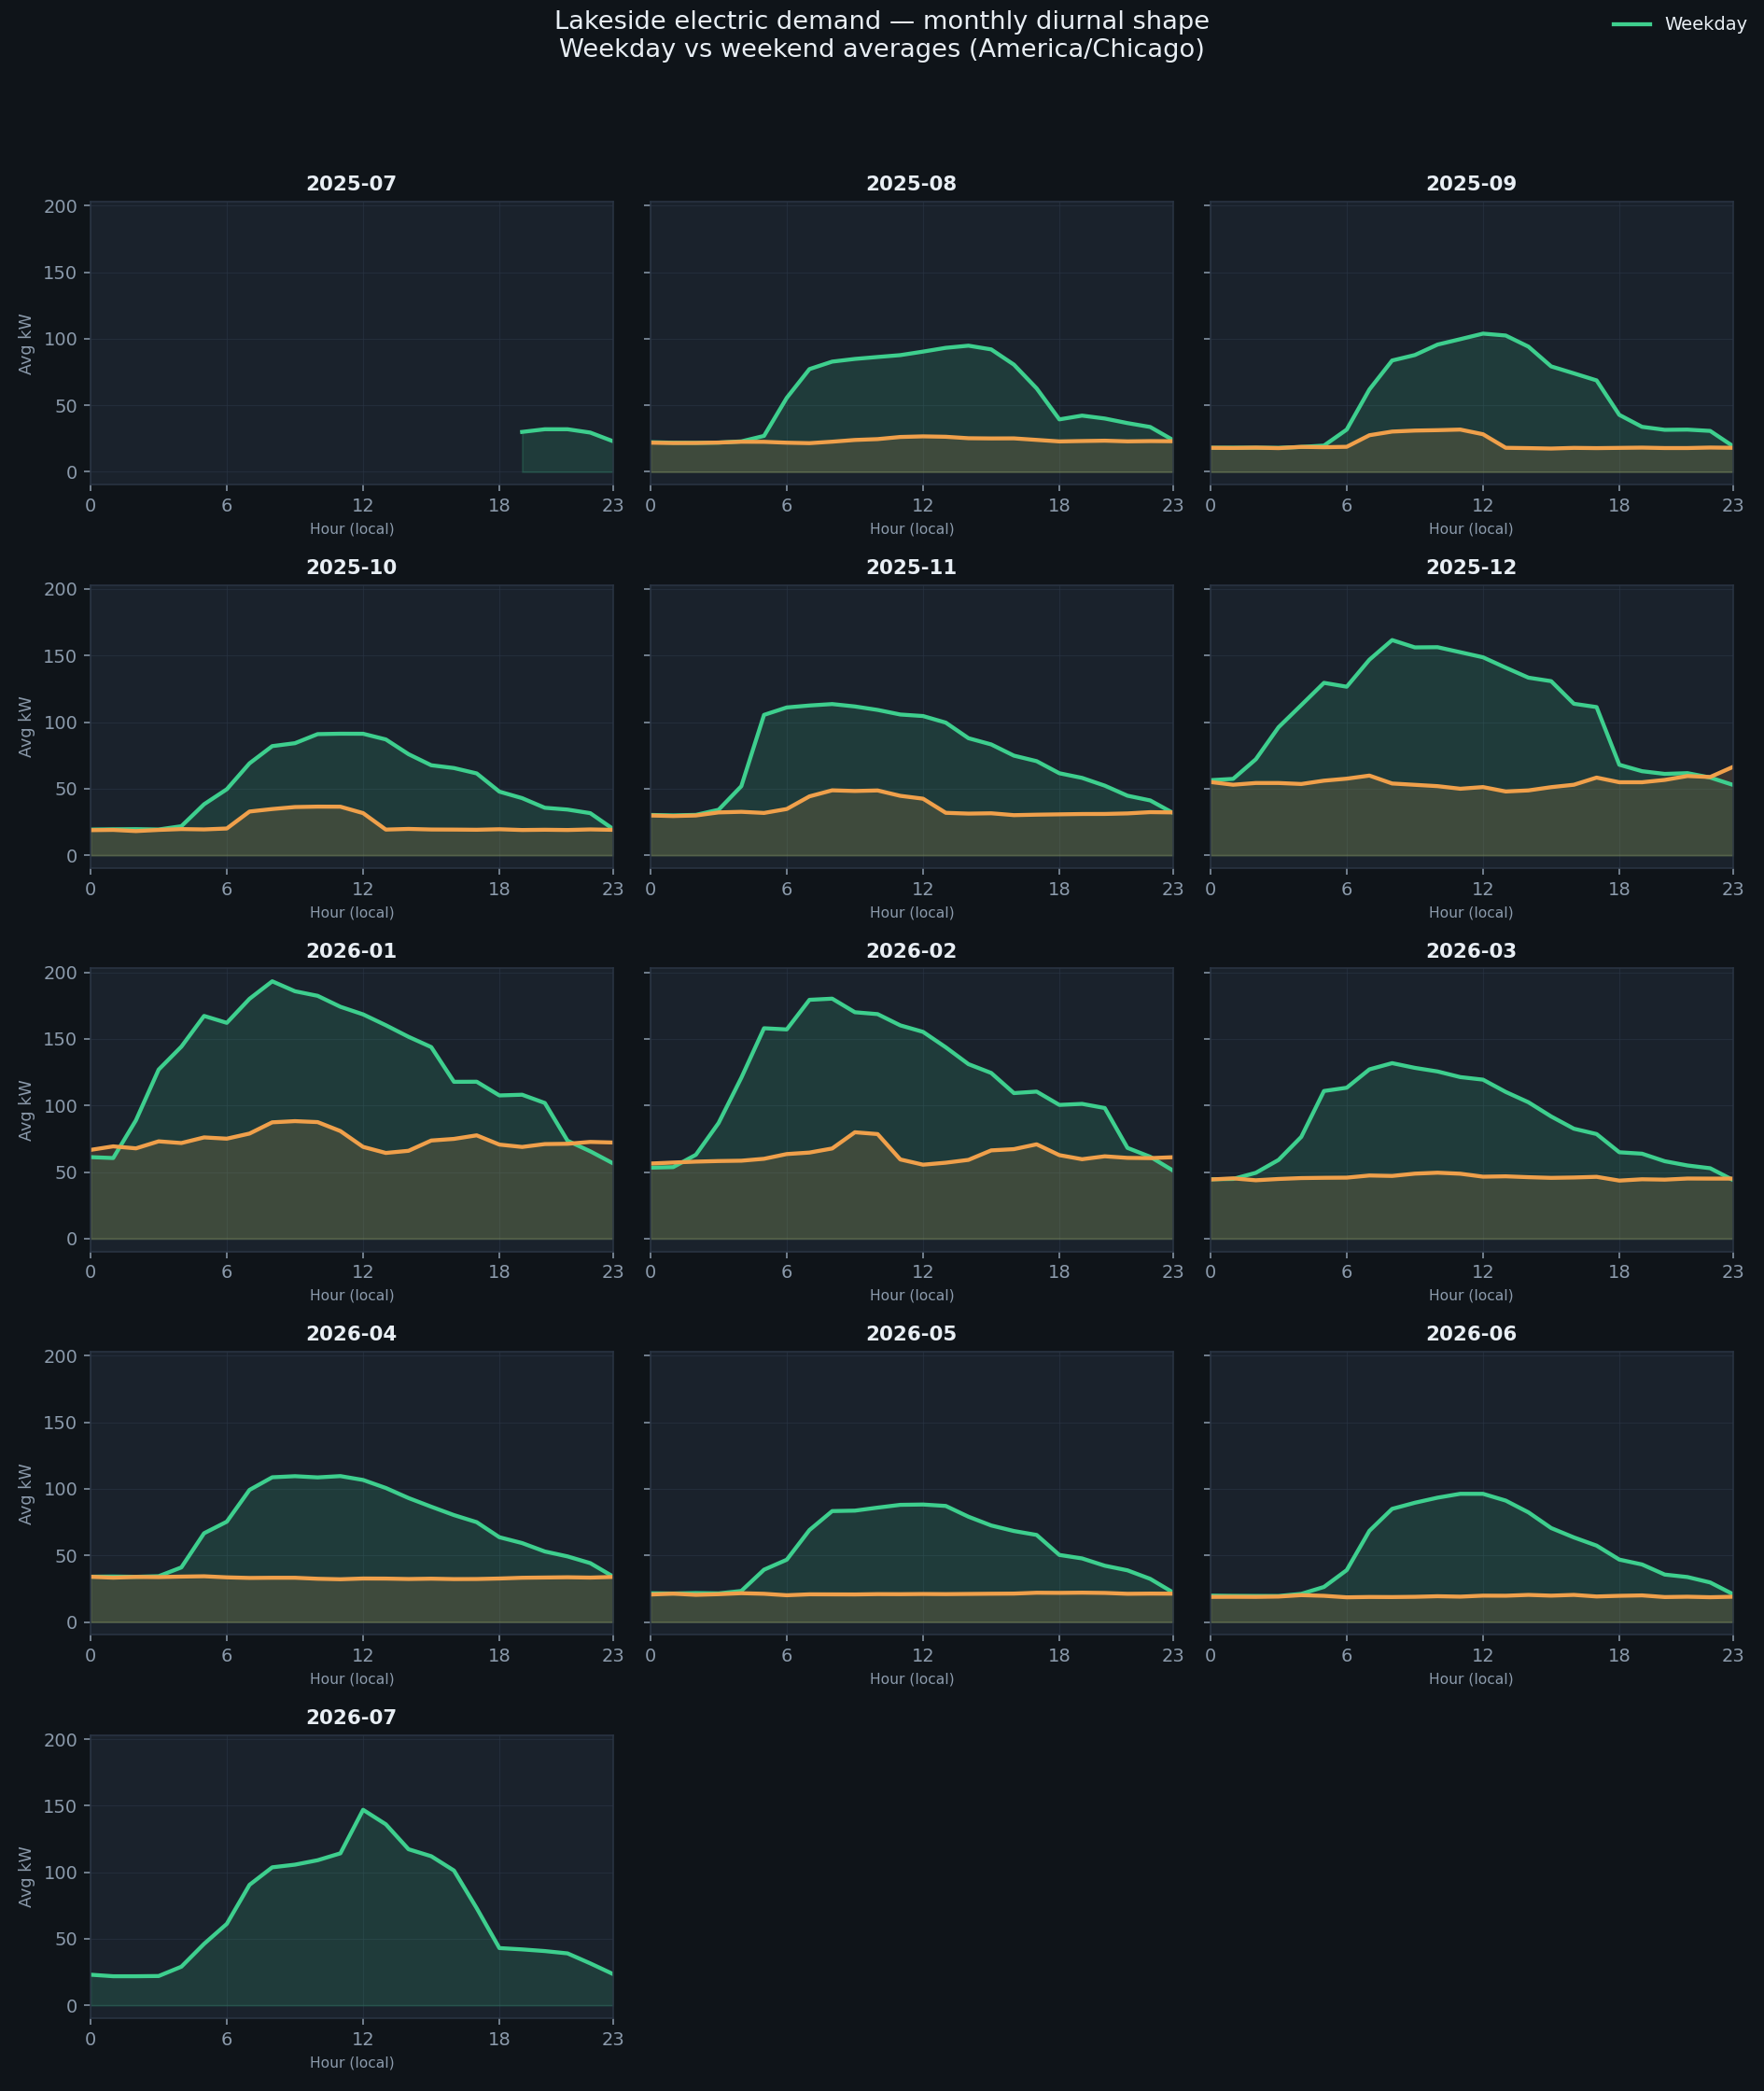

### `demand_vs_web_weather_scatter.png`

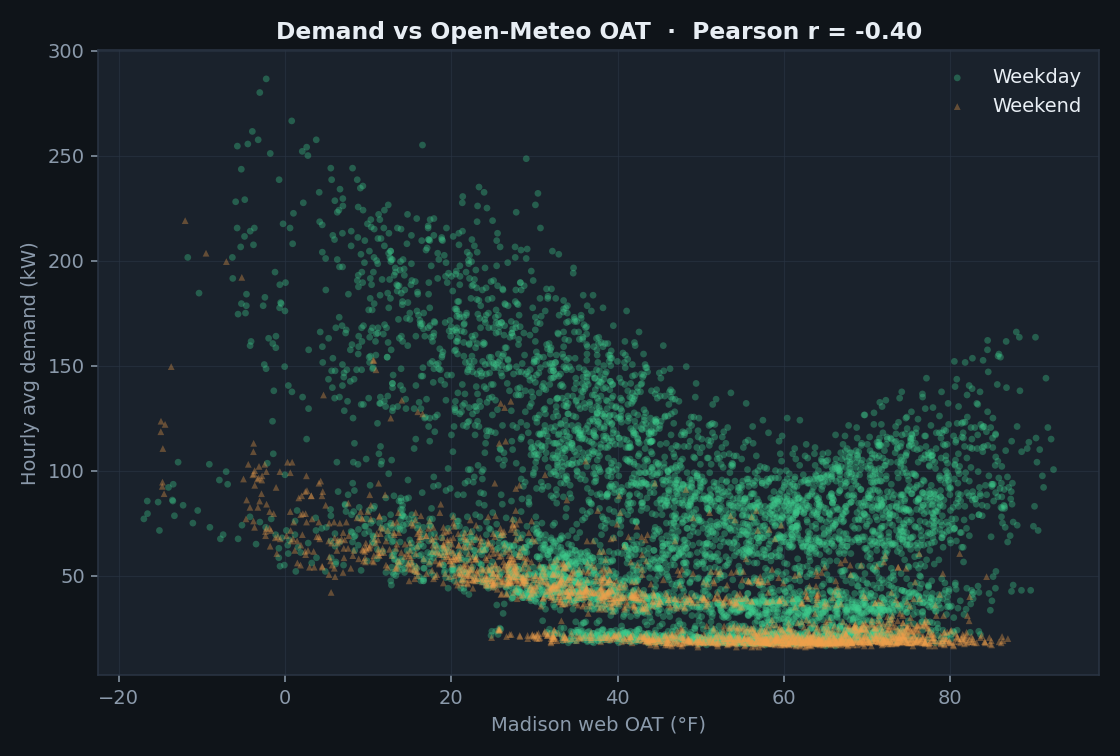

### `demand_vs_web_weather_density.png`

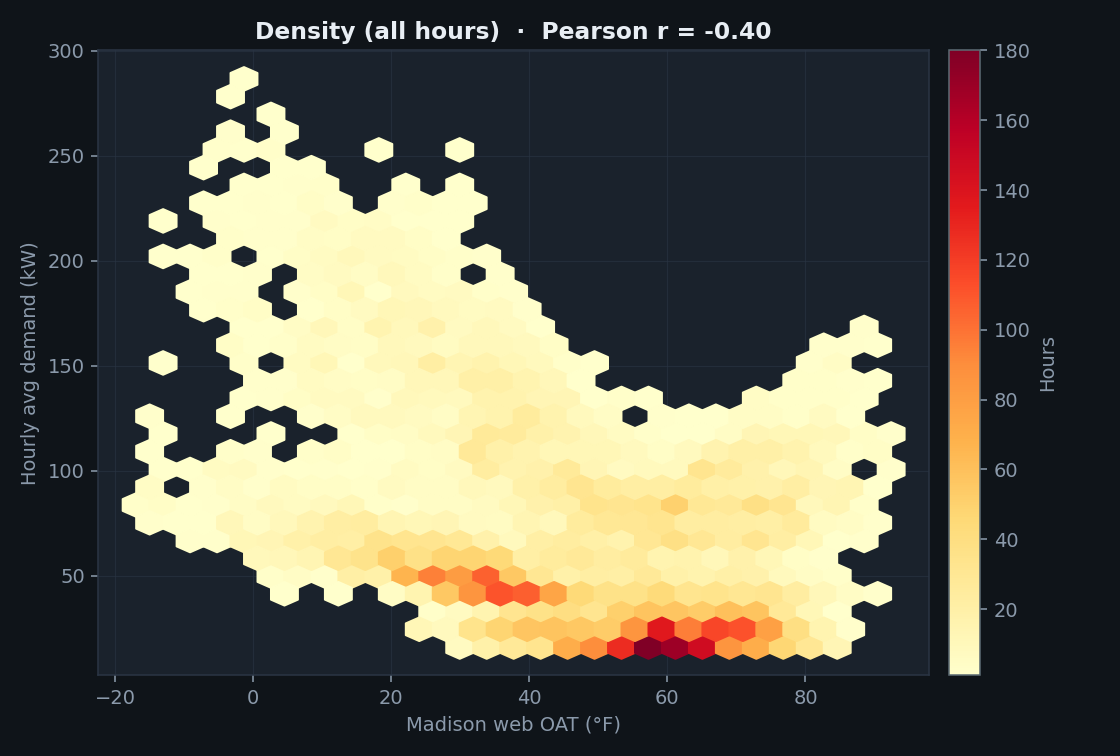

### `demand_vs_web_weather_scatter_peak_day.png`

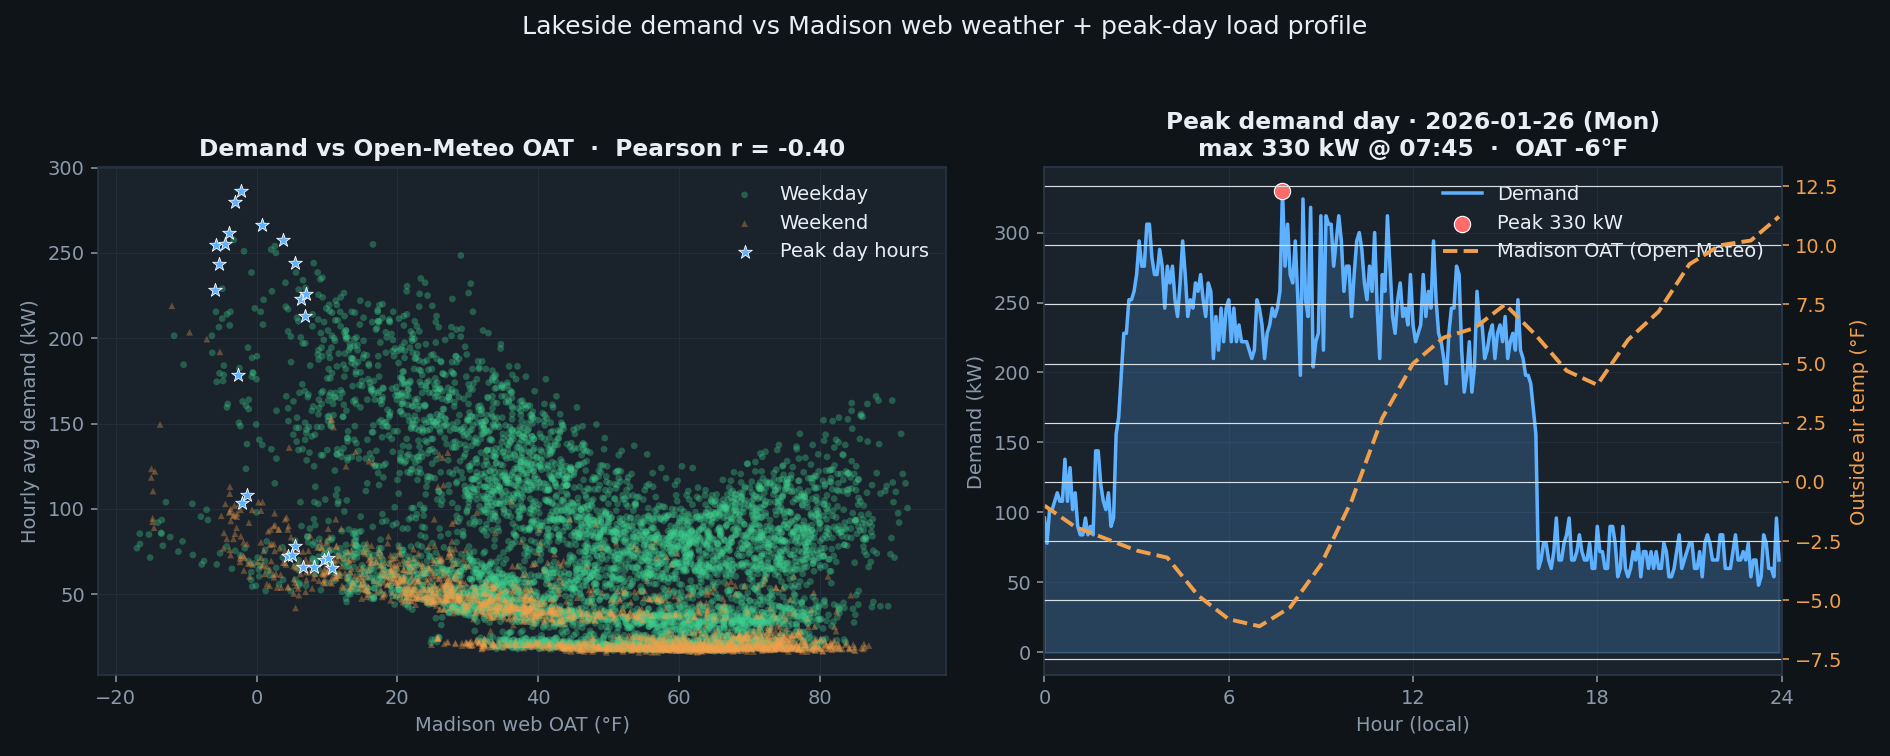

### `gl14_progress_by_iteration.png`

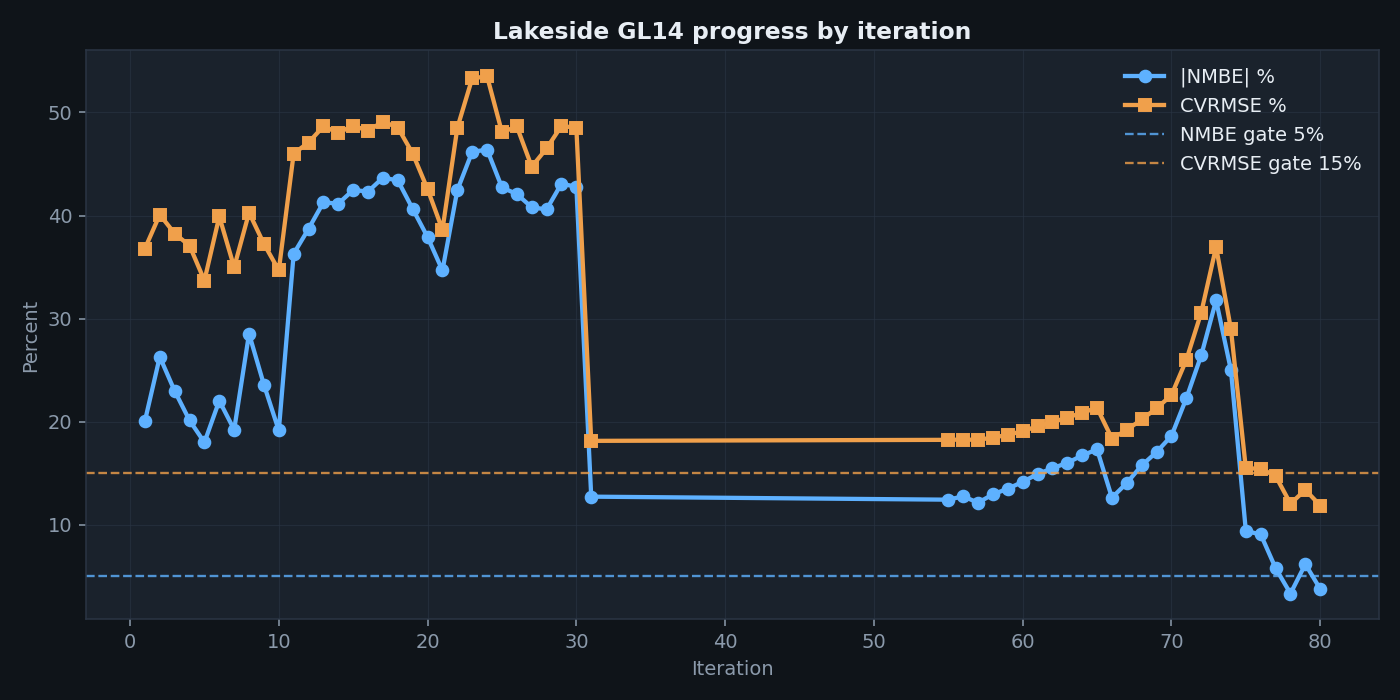

### `gl14_status_by_iteration.png`

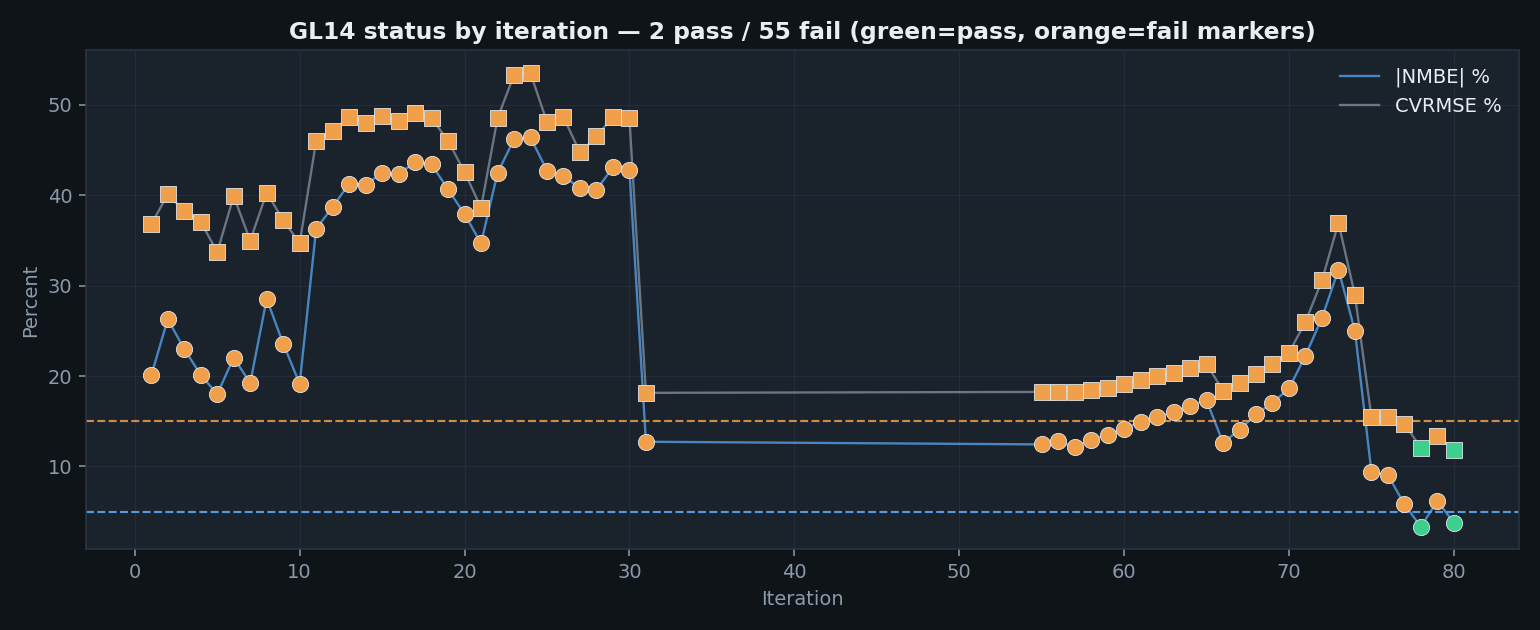

### `monthly_error_heatmap.png`

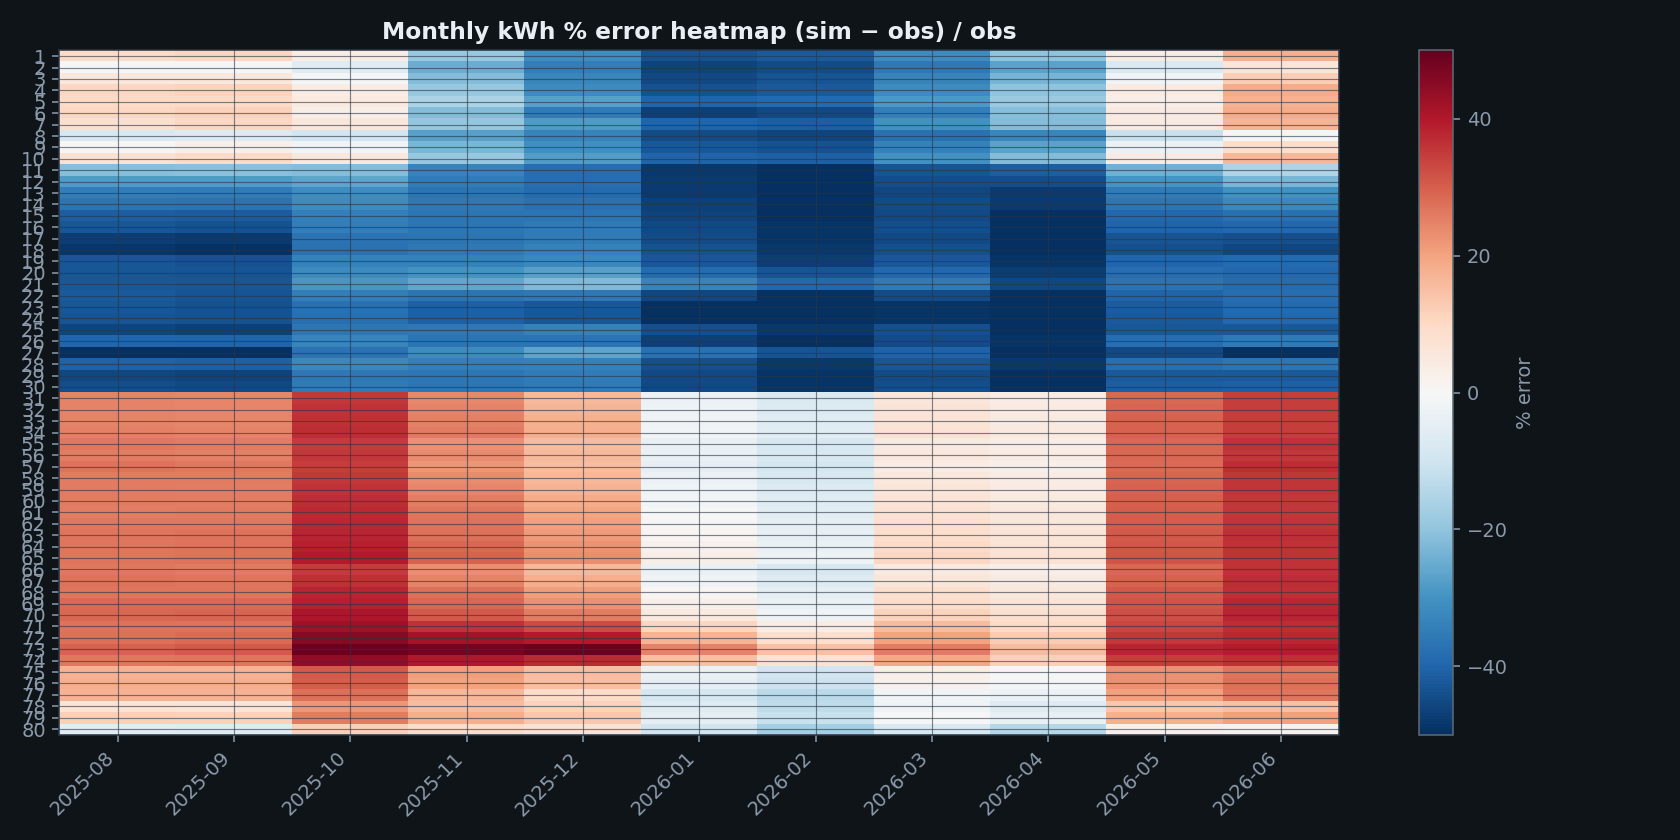

displayed 8 / 8


In [ ]:
from demand_weather_charts import regenerate_analytics_charts

ALLOW_WEATHER_FETCH = os.environ.get("VIBE22_ALLOW_WEATHER_FETCH", "0") == "1"
written = regenerate_analytics_charts(allow_weather_fetch=ALLOW_WEATHER_FETCH)
print("wrote/refreshed", len(written), "charts")

WANT = [
    "demand_weekday_weekend_summary.png",
    "demand_monthly_weekday_weekend_profiles.png",
    "demand_vs_web_weather_scatter.png",
    "demand_vs_web_weather_density.png",
    "demand_vs_web_weather_scatter_peak_day.png",
    "gl14_progress_by_iteration.png",
    "gl14_status_by_iteration.png",
    "monthly_error_heatmap.png",
]

shown = 0
for name in WANT:
    p = ANALYTICS / name
    display(Markdown(f"### `{name}`"))
    if p.is_file():
        try:
            display(Image(filename=str(p)))
            shown += 1
        except Exception as e:
            print("display failed", p, e)
    else:
        display(Markdown(
            f"*Missing `{p}` — meter/weather/GL14 inputs may be absent. "
            f"Set `VIBE22_ALLOW_WEATHER_FETCH=1` to pull Open-Meteo if weather CSV is missing.*"
        ))
print("displayed", shown, "/", len(WANT))


## Example winter day (BAS frame)

One cold-season day from the real-baseline training store — facility kW + zones + OAT.


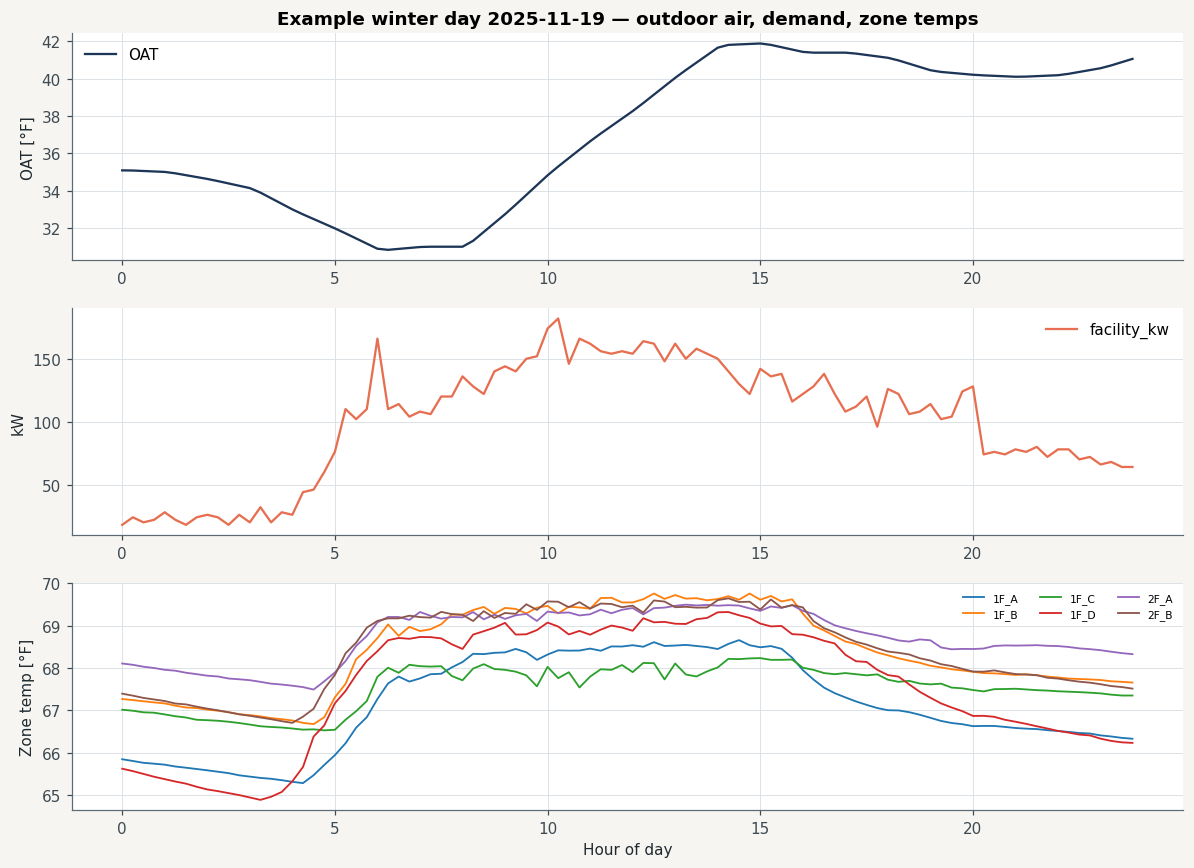

BAS example day 2025-11-19 rows 96


In [ ]:
bas_day = None
bas = None
try:
    from train_real_baseline_15min import load_real_baseline_frame
    from training_profile import require_profile
    prof = require_profile(os.environ.get("VIBE22_TRAINING_PROFILE", "smoke"))
    bas = load_real_baseline_frame(winter_only=True, max_days=prof.max_days, profile=prof)
    days = sorted(bas["day"].astype(str).unique())
    bas_day = days[len(days) // 2]
    fig = winter_day_panel(bas, bas_day)
    save_fig(FIG / "analysis_bas_winter_day.png", fig)
    plt.close(fig)
    print("BAS example day", bas_day, "rows", (bas["day"].astype(str) == bas_day).sum())
except Exception as e:
    display(Markdown(f"BAS frame unavailable: `{e}`"))


## Shape gallery — peak demand day (+ E+ weather match)

Uses the **exact same peak day** as `demand_vs_web_weather_scatter_peak_day.png`
(local calendar day of max 5-min meter kW).

- **Actual / ML** — that calendar day  
- **EnergyPlus** — same day if farmed; otherwise **best OAT-matched** baseline farm day
  (labeled with OAT RMSE — a shape proxy, not a silent day swap)


### Notes
- Anchor = peak meter day 2026-01-26 (max 5-min kW=330.0 at 2026-01-26 07:45:00-06:00) — same rule as demand_vs_web_weather_scatter_peak_day.png
- No E+ farm day for 2026-01-26; showing best OAT-matched baseline 2026-01-11 (hourly OAT RMSE=26.49°F). Shape proxy — not same calendar day.

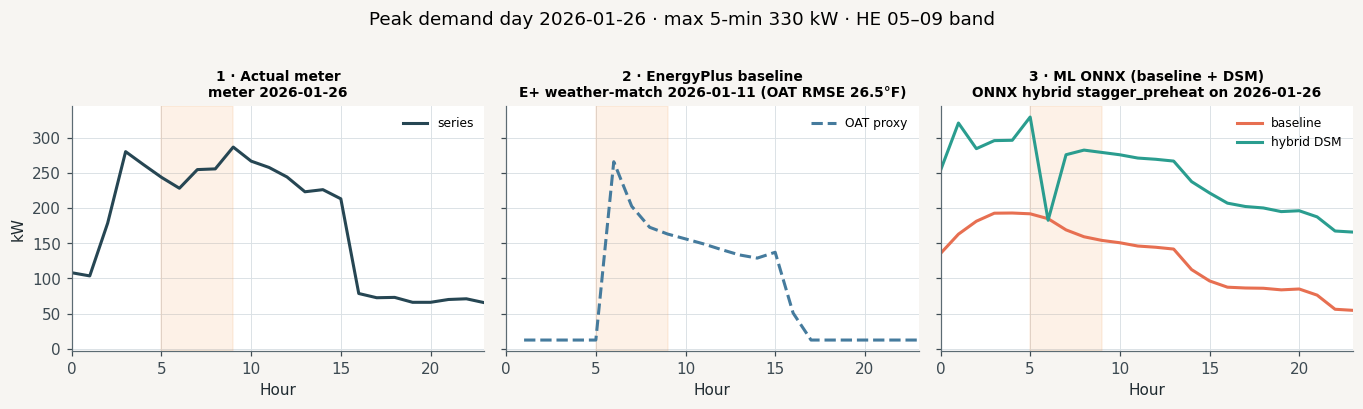

- **Peak day:** `2026-01-26` at `2026-01-26 07:45:00-06:00` (330.0 kW)
- Actual: **meter 2026-01-26**
- EnergyPlus: **E+ weather-match 2026-01-11 (OAT RMSE 26.5°F)**
- ML: **ONNX hybrid stagger_preheat on 2026-01-26**


In [ ]:
import sys
sys.modules.pop("peak_day_shape_gallery", None)
from peak_day_shape_gallery import build_peak_day_gallery

# Prefer full BAS coverage so the peak day is present for ONNX init/weather
bas_full = None
try:
    from train_real_baseline_15min import load_real_baseline_frame
    bas_full = load_real_baseline_frame(winter_only=False, max_days=None)
except Exception as e:
    print("BAS full load skipped:", e)
    bas_full = bas  # fall back to earlier smoke/profile frame if any

gallery = build_peak_day_gallery(
    meter_csv=METER,
    paired_parquet=OUT / "heating_dsm_eplus_paired_15min_v1.parquet",
    artifacts_dir=OUT,
    bas=bas_full,
    strategy_id="stagger_preheat",
    weather_csv=CLEAN / "weather" / "history_wide.csv",
    allow_eplus_weather_match=True,
)

hour = np.arange(24, dtype=float)
actual_kw = gallery.actual_kw
eplus_kw = gallery.eplus_kw
ml_base = gallery.ml_baseline_kw
ml_hyb = gallery.ml_hybrid_kw
labels = gallery.labels

display(Markdown("### Notes\n- " + "\n- ".join(gallery.notes)))

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6), sharey=True)
panels = [
    (axes[0], actual_kw, None, labels["actual"], "1 · Actual meter", "#264653"),
    (axes[1], eplus_kw, None, labels["eplus"], "2 · EnergyPlus baseline", "#457b9d"),
    (axes[2], ml_base, ml_hyb, labels["ml"], "3 · ML ONNX (baseline + DSM)", "#e76f51"),
]
eplus_is_proxy = "weather-match" in str(labels.get("eplus", ""))
for ax, a, b, lab, title, color in panels:
    ax.axvspan(5, 9, color="#f4a261", alpha=0.15)
    ls = "--" if (ax is axes[1] and eplus_is_proxy) else "-"
    if a is not None and np.isfinite(a).any():
        ax.plot(
            hour,
            a,
            color=color,
            lw=2.0,
            ls=ls,
            label=("OAT proxy" if ls == "--" else "series") if b is None else "baseline",
        )
    if b is not None and np.isfinite(b).any():
        ax.plot(hour, b, color="#2a9d8f", lw=2.0, label="hybrid DSM")
    ax.set_title(f"{title}\n{lab}", fontsize=9)
    ax.set_xlabel("Hour")
    ax.set_xlim(0, 23)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if a is None or not np.isfinite(np.asarray(a, dtype=float)).any():
        ax.text(0.5, 0.5, "no data\nfor peak day", ha="center", va="center",
                transform=ax.transAxes, color="#888", fontsize=10)
    else:
        ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel("kW")
fig.suptitle(
    f"Peak demand day {gallery.peak_day} · max 5-min {gallery.peak_kw:.0f} kW · HE 05–09 band",
    fontsize=12,
    y=1.02,
)
fig.tight_layout()
save_fig(FIG / "analysis_shape_gallery_peak_day.png", fig)
plt.close(fig)

display(Markdown(
    f"- **Peak day:** `{gallery.peak_day}` at `{gallery.peak_ts_local}` ({gallery.peak_kw:.1f} kW)\n"
    f"- Actual: **{labels['actual']}**\n"
    f"- EnergyPlus: **{labels['eplus']}**\n"
    f"- ML: **{labels['ml']}**\n"
))


## Quick read

- Gallery anchor is the **meter peak day** (same as the peak-day weather scatter).
- If E+ has no farm day for that date, the middle panel uses the **best OAT-matched** IdealLoads day (dashed = proxy).
- ML panel is a live ONNX hybrid walk for the peak calendar day.
